In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

ModuleNotFoundError: No module named 'seaborn'

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
df = pd.read_csv("credit_scoring_cleaned.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (150000, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [5]:
print("Dataset Information")
print("-------------------")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Information
-------------------
Rows: 150000
Columns: 11

Column Names:
['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']

Missing Values:
SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64


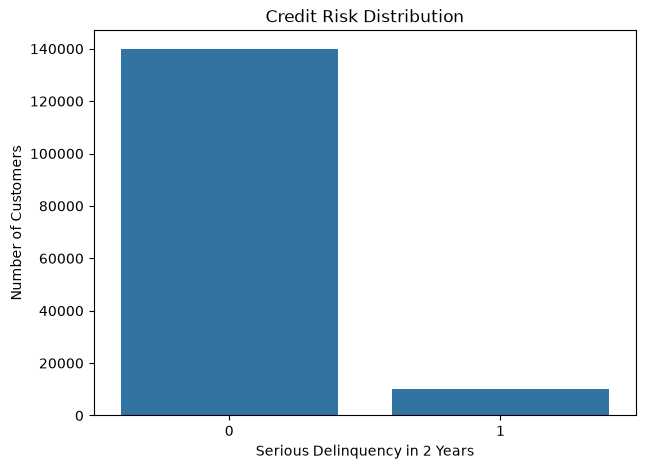

In [6]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="SeriousDlqin2yrs")

plt.title("Credit Risk Distribution")
plt.xlabel("Serious Delinquency in 2 Years")
plt.ylabel("Number of Customers")

plt.show()

In [7]:
df.describe()


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.500000e+05,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.418455e+03,8.452760,0.265973,1.018240,0.240387,0.737413
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.289040e+04,5.145951,4.169304,1.129771,4.155179,1.107021
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.903000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,7.400000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


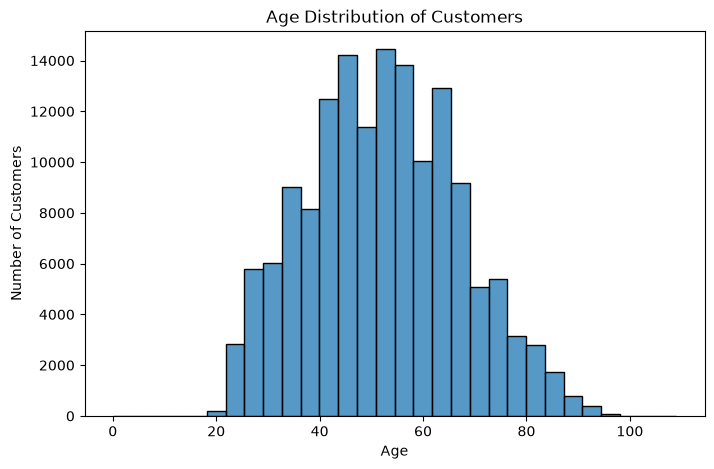

In [8]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="age", bins=30)

plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

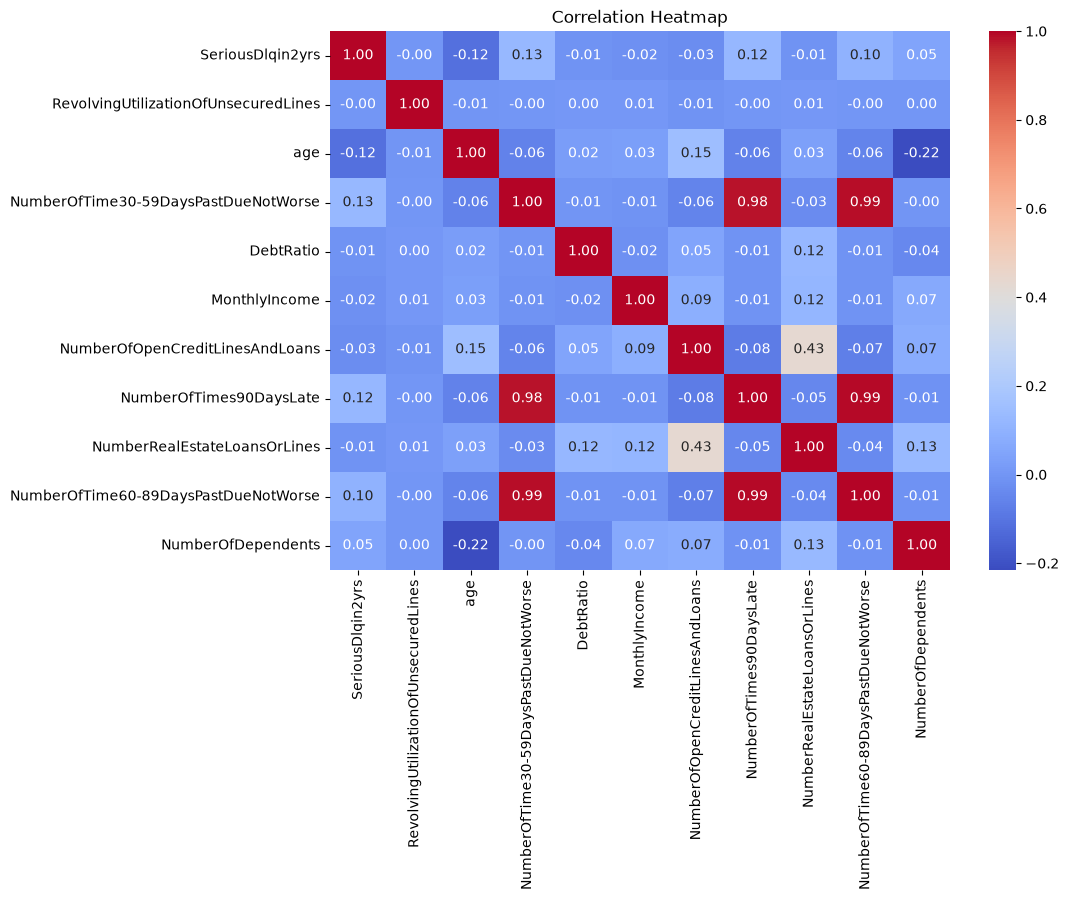

In [9]:
plt.figure(figsize=(10, 7))

correlation = df.corr(numeric_only=True)

sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

In [10]:
X = df.drop("SeriousDlqin2yrs", axis=1)
y = df["SeriousDlqin2yrs"]

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Features (X) shape: (150000, 10)
Target (y) shape: (150000,)


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (120000, 10)
Testing features: (30000, 10)
Training target: (120000,)
Testing target: (30000,)


In [12]:
print("Training class distribution:")
print(y_train.value_counts())

print("\nTraining class percentage:")
print(y_train.value_counts(normalize=True) * 100)

Training class distribution:
SeriousDlqin2yrs
0    111979
1      8021
Name: count, dtype: int64

Training class percentage:
SeriousDlqin2yrs
0    93.315833
1     6.684167
Name: proportion, dtype: float64


In [13]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [14]:
y_pred = model.predict(X_test)

print("Predictions generated successfully!")
print("Number of predictions:", len(y_pred))

Predictions generated successfully!
Number of predictions: 30000


In [15]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Model Evaluation")
print("----------------")
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-Score:", round(f1, 4))

Model Evaluation
----------------
Precision: 0.4301
Recall: 0.3666
F1-Score: 0.3958


In [16]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", round(roc_auc, 4))

ROC-AUC: 0.8466


Confusion Matrix:
[[27021   974]
 [ 1270   735]]


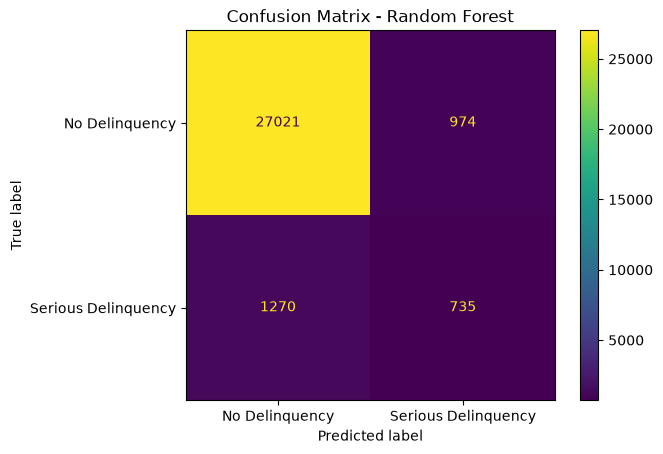

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Delinquency", "Serious Delinquency"]
)

disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

                                Feature  Importance
0  RevolvingUtilizationOfUnsecuredLines    0.270910
3                             DebtRatio    0.140353
1                                   age    0.115668
4                         MonthlyIncome    0.115256
6               NumberOfTimes90DaysLate    0.089221
2  NumberOfTime30-59DaysPastDueNotWorse    0.084287
5       NumberOfOpenCreditLinesAndLoans    0.077436
8  NumberOfTime60-89DaysPastDueNotWorse    0.042969
7          NumberRealEstateLoansOrLines    0.031985
9                    NumberOfDependents    0.031915


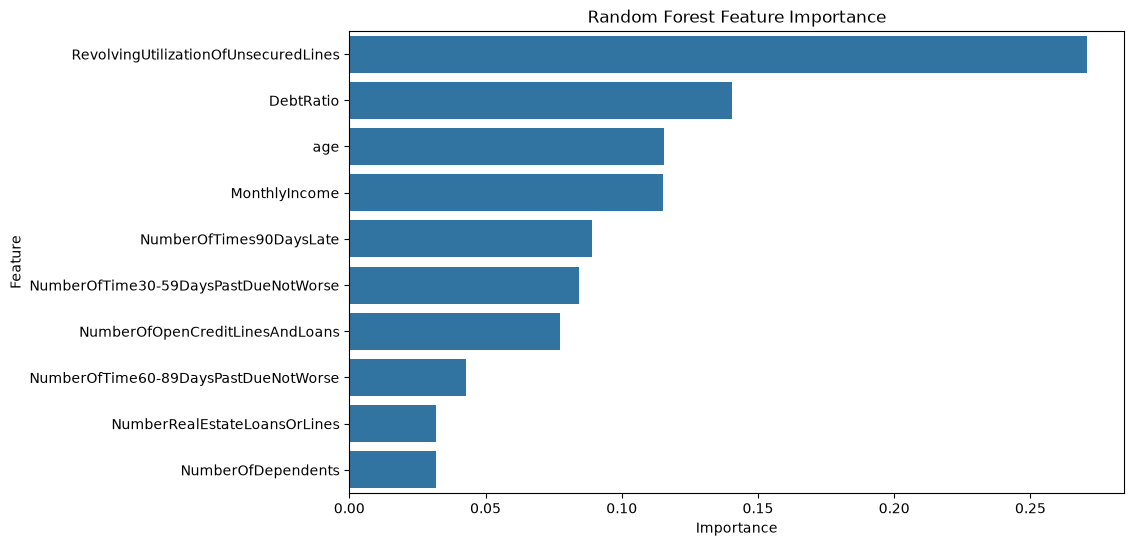

In [18]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [19]:
results = pd.DataFrame({
    "Metric": ["Precision", "Recall", "F1-Score", "ROC-AUC"],
    "Score": [precision, recall, f1, roc_auc]
})

results["Score"] = results["Score"].round(4)

results

,Metric,Score
0,Precision,0.4301
1,Recall,0.3666
2,F1-Score,0.3958
3,ROC-AUC,0.8466


In [20]:
import joblib

joblib.dump(model, "credit_scoring_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [21]:
results.to_csv("model_results.csv", index=False)

print("Model results saved successfully!")

Model results saved successfully!


## Conclusion

A Random Forest classification model was developed to predict serious delinquency in two years using historical financial data.

The dataset was analyzed, cleaned, and prepared for machine learning. The data was split into training and testing sets, and the model was trained using class balancing to address the imbalanced target variable.

### Model Performance

- Precision: 0.4301
- Recall: 0.3666
- F1-Score: 0.3958
- ROC-AUC: 0.8466

The ROC-AUC score of 0.8466 indicates that the model has good ability to distinguish between customers with and without serious delinquency.

The most important features identified by the Random Forest model were:

1. RevolvingUtilizationOfUnsecuredLines
2. DebtRatio
3. age
4. MonthlyIncome
5. NumberOfTimes90DaysLate

Overall, the project demonstrates how machine learning can be applied to financial data to assess credit risk and predict the likelihood of serious delinquency.